# Alchemical free energy: four estimators over one set of samples

The FEP and TI analysis of a prepared leg -- `md-openmm build-md` produced it, the windows ran,
and `md_tools.alchemy.campaign.analyze_leg` reads what they wrote.

**Four estimators over identical samples are not four measurements.** MBAR, BAR, TI and the two
EXP directions are four probes of ONE dataset. Their spread says how well the ladder overlaps,
not how uncertain the free energy is. The uncertainty comes from REPEATS.

**Point this at your own leg.** The path below is read from an environment variable, because a
committed notebook must not carry one machine's path:

```bash
export MD_ALCHEMY_LEG=/path/to/AHFE-leg1-run1
```

In [1]:
import os, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

KCAL_PER_KJ = 1.0 / 4.184

run = os.environ.get("MD_ALCHEMY_LEG")
if not run:
    raise RuntimeError(
        "set MD_ALCHEMY_LEG to a prepared leg directory, e.g.\n"
        "    export MD_ALCHEMY_LEG=/path/to/AHFE-leg1-run1\n"
        "It is not defaulted because a default would be one machine's path.")
leg = Path(run) / "leg"
if not (leg / "leg.json").is_file():
    raise RuntimeError(f"{leg} is not a prepared leg; give the directory build-md generated")
# The NAME only, never the path, for the reason in the setup cell of the other
# notebooks: an executed notebook stores whatever it printed.
print("leg:", leg.parent.name + "/leg")

leg: AHFE-leg1-run1/leg


## What the windows wrote

`w000.samples.csv` is where the free energy lives. Each row is one configuration's energy
evaluated at EVERY state of the ladder, plus `dU/dlambda` at its own state -- the cross-state
block is what MBAR and BAR consume, and the derivative column is what TI integrates.

In [2]:
import pandas as pd

windows = sorted((leg / "windows" / "r1").glob("*.samples.csv"))
print(f"{len(windows)} windows")
first = pd.read_csv(windows[0])
energy_columns = [c for c in first.columns if c.startswith("U_w")]
deriv_columns = [c for c in first.columns if c.startswith("dU_dlambda")]
print(f"{len(first)} rows in w000; {len(energy_columns)} cross-state energies, "
      f"{len(deriv_columns)} derivative columns")
print("derivatives:", ", ".join(c.replace("dU_dlambda_", "").replace("_kJ_mol", "")
                                for c in deriv_columns))

12 windows
1001 rows in w000; 12 cross-state energies, 5 derivative columns
derivatives: angles, bonds, electrostatics, sterics, torsions


Note there is a derivative column PER LAMBDA COMPONENT -- electrostatics, sterics, bonds, angles,
torsions -- because the path moves them on separate schedules. TI integrates the sum.

In [3]:
from md_tools.alchemy.campaign import analyze_leg

record, analysis = analyze_leg(leg, repeat="r1", estimator="MBAR")

# The sign: the leg DECOUPLES the molecule, so the hydration free energy is the negative.
print(f"dG_hyd (MBAR)   {-record.delta_g_kj_mol * KCAL_PER_KJ:+8.3f} "
      f"+/- {record.sigma_kj_mol * KCAL_PER_KJ:.3f} kcal/mol")
print()
for name in ("MBAR", "BAR", "TI", "EXP_forward", "EXP_reverse"):
    estimate = analysis["estimates"].get(name)
    if estimate is not None:
        print(f"  {name:12s} {-estimate['delta_g_kJ_mol'] * KCAL_PER_KJ:+8.3f} kcal/mol")

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.


dG_hyd (MBAR)     -3.787 +/- 0.103 kcal/mol

  MBAR           -3.787 kcal/mol
  BAR            -3.650 kcal/mol
  TI             -4.147 kcal/mol
  EXP_forward    -3.839 kcal/mol
  EXP_reverse    -3.659 kcal/mol


## The diagnostic that decides whether to believe any of it

Neighbouring states must share configuration space, or no estimator can bridge them. The overlap
is the number to read FIRST -- before the free energy, not after it.

In [4]:
diagnostics = analysis["estimates"]["MBAR"]["diagnostics"]
print(f"smallest neighbour overlap  {diagnostics['min_neighbour_overlap']:.3f}"
      f"   (a ladder is in trouble below ~0.03)")
print(f"poor overlap anywhere       {diagnostics['poor_overlap']}")
print(f"samples per window          {min(diagnostics['samples_per_state'])}"
      f"-{max(diagnostics['samples_per_state'])} after decorrelation")

smallest neighbour overlap  0.178   (a ladder is in trouble below ~0.03)
poor overlap anywhere       False
samples per window          227-412 after decorrelation


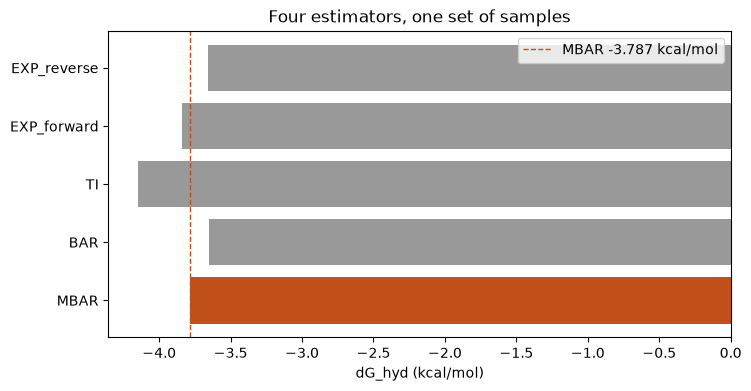

In [5]:
names, values = [], []
for name in ("MBAR", "BAR", "TI", "EXP_forward", "EXP_reverse"):
    estimate = analysis["estimates"].get(name)
    if estimate is not None:
        names.append(name)
        values.append(-estimate["delta_g_kJ_mol"] * KCAL_PER_KJ)

fig, ax = plt.subplots(figsize=(7.4, 3.8), layout="constrained")
ax.barh(names, values, color=["#C1501A" if n == "MBAR" else "0.6" for n in names])
ax.axvline(values[0], color="#C1501A", ls="--", lw=1,
           label=f"MBAR {values[0]:+.3f} kcal/mol")
ax.set_xlabel("dG_hyd (kcal/mol)")
ax.set_title("Four estimators, one set of samples")
ax.legend()

## What the spread does and does not mean

If the estimators agree, the ladder overlaps well and the sampling supports all of them. If they
disagree, look at the overlap before the physics: EXP in one direction is the first to break,
because an exponential average is carried by its tail.

**MBAR far from BAR would mean something is wrong with the samples themselves**, not with the
choice of estimator.

And the uncertainty quoted above is MBAR's asymptotic covariance for ONE ladder. It is not the
error bar to publish -- repeat the leg and take the spread across repeats. Of the two, the repeat
spread is almost always the larger, and it is the honest one.